In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

file_path = '/content/bank_clients_transactions.csv'  # ← замени на свой путь
df = pd.read_csv(file_path)

print("✅ Данные загружены!")
print(df.head())
print("\n📋 Колонки:", df.columns.tolist())
print(f"\n📊 Размер: {df.shape[0]} строк, {df.shape[1]} колонок")

✅ Данные загружены!
  TransactionID CustomerID CustomerDOB CustGender CustLocation  \
0            T1   C5841053     10/1/94          F   JAMSHEDPUR   
1            T2   C2142763      4/4/57          M      JHAJJAR   
2            T3   C4417068    26/11/96          F       MUMBAI   
3            T4   C5342380     14/9/73          F       MUMBAI   
4            T5   C9031234     24/3/88          F  NAVI MUMBAI   

   CustAccountBalance TransactionDate  TransactionTime  \
0            17819.05          2/8/16         143207.0   
1             2270.69          2/8/16         141858.0   
2            17874.44          2/8/16         142712.0   
3           866503.21          2/8/16         142714.0   
4             6714.43          2/8/16         181156.0   

   TransactionAmount (INR)  
0                     25.0  
1                  27999.0  
2                    459.0  
3                   2060.0  
4                   1762.5  

📋 Колонки: ['TransactionID', 'CustomerID', 'CustomerDOB', '

In [3]:
# Функция для преобразования в camelCase
def to_camel_case(snake_str):
    components = snake_str.lower().split('_')
    return components[0] + ''.join(x.title() for x in components[1:])

df.columns = [to_camel_case(col) for col in df.columns]
print("📋 Новые названия колонок:", df.columns.tolist())

📋 Новые названия колонок: ['transactionid', 'customerid', 'customerdob', 'custgender', 'custlocation', 'custaccountbalance', 'transactiondate', 'transactiontime', 'transactionamount (inr)']


In [4]:
# Смотрим типы
print(df.dtypes)

# Если есть колонка с датой — преобразуем
date_cols = ['transaction_date', 'birth_date', 'date']  # список возможных названий
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col])
        print(f"✅ {col} преобразован в datetime")

transactionid               object
customerid                  object
customerdob                 object
custgender                  object
custlocation                object
custaccountbalance         float64
transactiondate             object
transactiontime            float64
transactionamount (inr)    float64
dtype: object


In [5]:
print(f"Было строк: {len(df)}")

# Пропуски
print("Пропуски:")
print(df.isna().sum())
df = df.dropna()

# Дубликаты
print(f"Дубликатов: {df.duplicated().sum()}")
df = df.drop_duplicates()

print(f"Стало строк: {len(df)}")

Было строк: 230833
Пропуски:
transactionid                0
customerid                   0
customerdob                753
custgender                 233
custlocation                41
custaccountbalance         628
transactiondate              1
transactiontime              1
transactionamount (inr)      1
dtype: int64
Дубликатов: 0
Стало строк: 229193


In [6]:
# Уникальные клиенты
if 'clientId' in df.columns:
    unique_clients = df['clientId'].nunique()
elif 'customerId' in df.columns:
    unique_clients = df['customerId'].nunique()
else:
    unique_clients = len(df)

print(f"📊 Уникальных клиентов: {unique_clients}")
print(f"📊 Всего транзакций: {len(df)}")
print(f"📊 Среднее транзакций на клиента: {len(df)/unique_clients:.2f}")

📊 Уникальных клиентов: 229193
📊 Всего транзакций: 229193
📊 Среднее транзакций на клиента: 1.00


In [14]:
# Смотрим точные названия
print(df.columns.tolist())

['transactionid', 'customerid', 'customerdob', 'custgender', 'custlocation', 'custaccountbalance', 'transactiondate', 'transactiontime', 'transactionamount (inr)']


In [29]:
print("\n" + "="*50)
print("🔧 ИСПРАВЛЕНИЕ ДАННЫХ")
print("="*50)

# 1. Удаляем строки с некорректным возрастом (0-100 лет)
before = len(df)
df = df[(df['age'] >= 18) & (df['age'] <= 100)]
after = len(df)
print(f"✅ Удалено строк с некорректным возрастом: {before - after}")
print(f"✅ Осталось строк: {after}")

# 2. Смотрим, что осталось
print(f"\n📊 Возраст теперь:")
print(f"   Мин: {df['age'].min()}")
print(f"   Макс: {df['age'].max()}")
print(f"   Средний: {df['age'].mean():.1f}")


🔧 ИСПРАВЛЕНИЕ ДАННЫХ
✅ Удалено строк с некорректным возрастом: 0
✅ Осталось строк: 191877

📊 Возраст теперь:
   Мин: 18
   Макс: 50
   Средний: 38.5


In [30]:
print("\n" + "="*50)
print("5.1 ОБЩАЯ СТАТИСТИКА")
print("="*50)

# Твои колонки
customer_col = 'customerid'
amount_col = 'transactionamount (inr)'
date_col = 'transactiondate'

print(f"📊 Всего записей: {len(df)}")
print(f"📊 Всего клиентов: {df[customer_col].nunique()}")
print(f"📊 Общая выручка: {df[amount_col].sum():,.2f} INR")
print(f"📊 Средний чек: {df[amount_col].mean():.2f} INR")
print(f"📊 Медианный чек: {df[amount_col].median():.2f} INR")
print(f"📊 Среднее транзакций на клиента: {len(df) / df[customer_col].nunique():.2f}")


5.1 ОБЩАЯ СТАТИСТИКА
📊 Всего записей: 191877
📊 Всего клиентов: 185703
📊 Общая выручка: 247,314,630.61 INR
📊 Средний чек: 1288.92 INR
📊 Медианный чек: 385.00 INR
📊 Среднее транзакций на клиента: 1.03



5.2 РАСПРЕДЕЛЕНИЕ БАЛАНСА И СУММЫ ТРАНЗАКЦИЙ


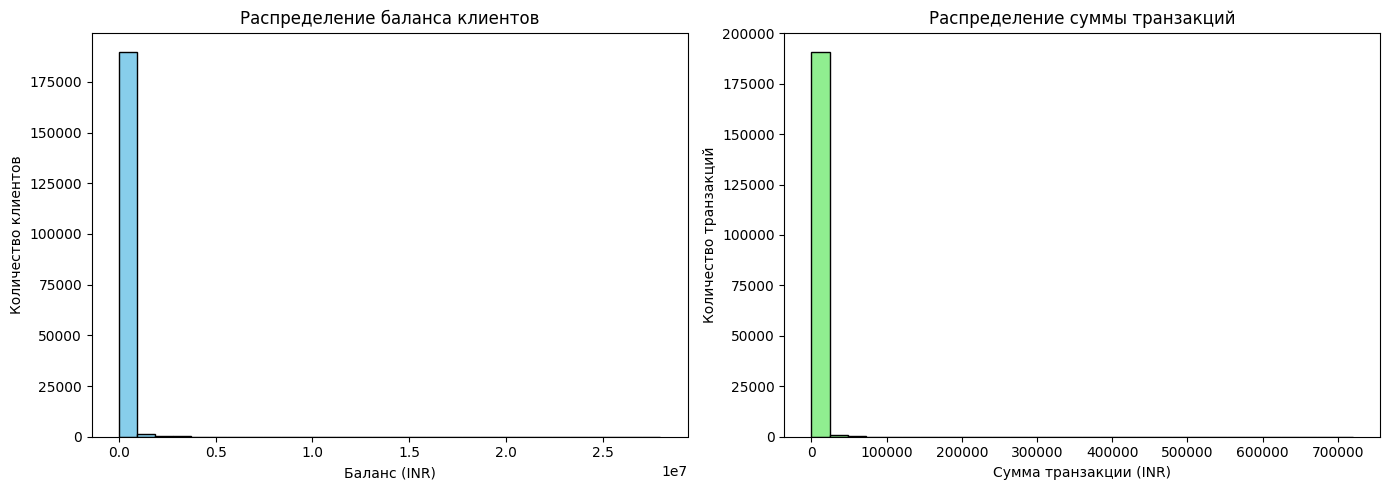


📊 Статистика по балансу:
   Средний: 71870.64 INR
   Медианный: 13739.94 INR

📊 Статистика по сумме транзакций:
   Средний: 1288.92 INR
   Медианный: 385.00 INR


In [31]:
print("\n" + "="*50)
print("5.2 РАСПРЕДЕЛЕНИЕ БАЛАНСА И СУММЫ ТРАНЗАКЦИЙ")
print("="*50)

balance_col = 'custaccountbalance'
amount_col = 'transactionamount (inr)'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Баланс
df[balance_col].hist(bins=30, ax=axes[0], edgecolor='black', color='skyblue')
axes[0].set_title('Распределение баланса клиентов', fontsize=12)
axes[0].set_xlabel('Баланс (INR)', fontsize=10)
axes[0].set_ylabel('Количество клиентов', fontsize=10)
axes[0].grid(False)

# Сумма транзакции
df[amount_col].hist(bins=30, ax=axes[1], edgecolor='black', color='lightgreen')
axes[1].set_title('Распределение суммы транзакций', fontsize=12)
axes[1].set_xlabel('Сумма транзакции (INR)', fontsize=10)
axes[1].set_ylabel('Количество транзакций', fontsize=10)
axes[1].grid(False)

plt.tight_layout()
plt.show()

print(f"\n📊 Статистика по балансу:")
print(f"   Средний: {df[balance_col].mean():.2f} INR")
print(f"   Медианный: {df[balance_col].median():.2f} INR")

print(f"\n📊 Статистика по сумме транзакций:")
print(f"   Средний: {df[amount_col].mean():.2f} INR")
print(f"   Медианный: {df[amount_col].median():.2f} INR")


5.3 ЯЩИК С УСАМИ ДЛЯ СУММЫ ТРАНЗАКЦИЙ
📊 Удалено выбросов: 20824


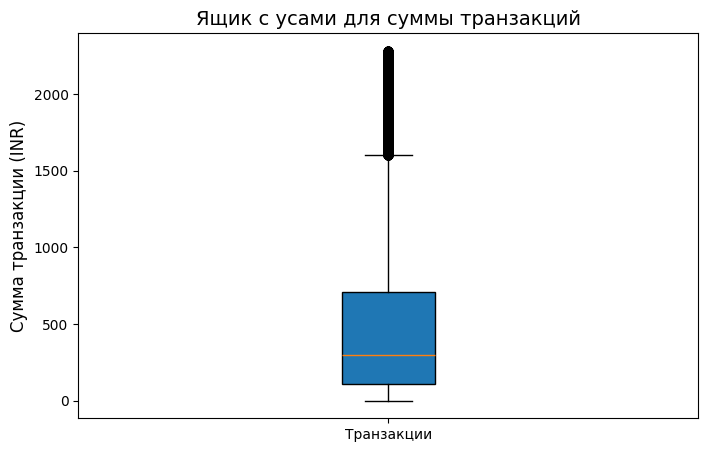


📊 Квартили:
   Q1: 145.00 INR
   Медиана: 385.00 INR
   Q3: 1000.00 INR
   IQR: 855.00 INR


In [32]:
print("\n" + "="*50)
print("5.3 ЯЩИК С УСАМИ ДЛЯ СУММЫ ТРАНЗАКЦИЙ")
print("="*50)

amount_col = 'transactionamount (inr)'

# Убираем выбросы для красивого графика
Q1 = df[amount_col].quantile(0.25)
Q3 = df[amount_col].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df_clean = df[(df[amount_col] >= lower) & (df[amount_col] <= upper)]

print(f"📊 Удалено выбросов: {len(df) - len(df_clean)}")

plt.figure(figsize=(8, 5))
plt.boxplot(df_clean[amount_col], patch_artist=True)
plt.title('Ящик с усами для суммы транзакций', fontsize=14)
plt.ylabel('Сумма транзакции (INR)', fontsize=12)
plt.xticks([1], ['Транзакции'])
plt.grid(False)
plt.show()

print(f"\n📊 Квартили:")
print(f"   Q1: {Q1:.2f} INR")
print(f"   Медиана: {df[amount_col].median():.2f} INR")
print(f"   Q3: {Q3:.2f} INR")
print(f"   IQR: {IQR:.2f} INR")


5.4 РАСПРЕДЕЛЕНИЕ ВОЗРАСТА КЛИЕНТОВ
📊 Средний возраст: 38.5 лет
📊 Медианный возраст: 38.0 лет


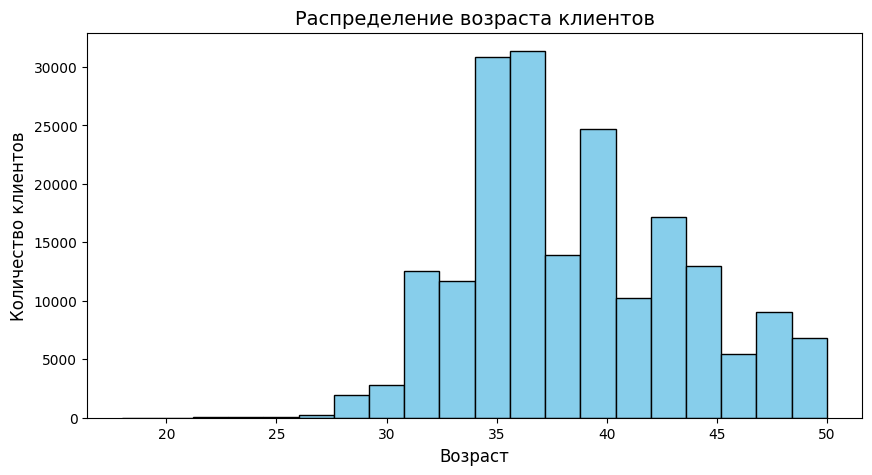

In [33]:
print("\n" + "="*50)
print("5.4 РАСПРЕДЕЛЕНИЕ ВОЗРАСТА КЛИЕНТОВ")
print("="*50)

print(f"📊 Средний возраст: {df['age'].mean():.1f} лет")
print(f"📊 Медианный возраст: {df['age'].median():.1f} лет")

plt.figure(figsize=(10, 5))
df['age'].hist(bins=20, edgecolor='black', color='skyblue')
plt.title('Распределение возраста клиентов', fontsize=14)
plt.xlabel('Возраст', fontsize=12)
plt.ylabel('Количество клиентов', fontsize=12)
plt.grid(False)
plt.show()


5.5 АНАЛИЗ ПОЛА
custgender
M    138123
F     53754
Name: count, dtype: int64


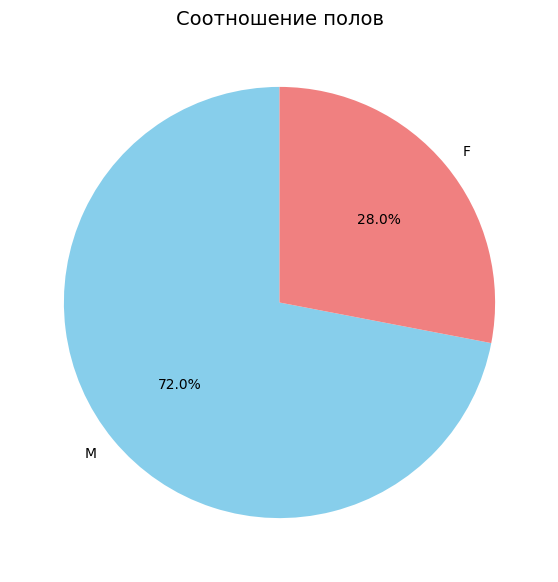

In [34]:
print("\n" + "="*50)
print("5.5 АНАЛИЗ ПОЛА")
print("="*50)

gender_counts = df['custgender'].value_counts()
print(gender_counts)

plt.figure(figsize=(7, 7))
plt.pie(gender_counts.values, labels=gender_counts.index,
        autopct='%1.1f%%', startangle=90,
        colors=['skyblue', 'lightcoral'])
plt.title('Соотношение полов', fontsize=14)
plt.show()


5.6 АНАЛИЗ ГОРОДОВ
📊 Всего городов: 4745
📊 Топ-10 городов:
   MUMBAI: 18594
   BANGALORE: 15927
   NEW DELHI: 14218
   GURGAON: 13738
   DELHI: 13226
   NOIDA: 6166
   CHENNAI: 5117
   PUNE: 4700
   HYDERABAD: 4414
   THANE: 4248


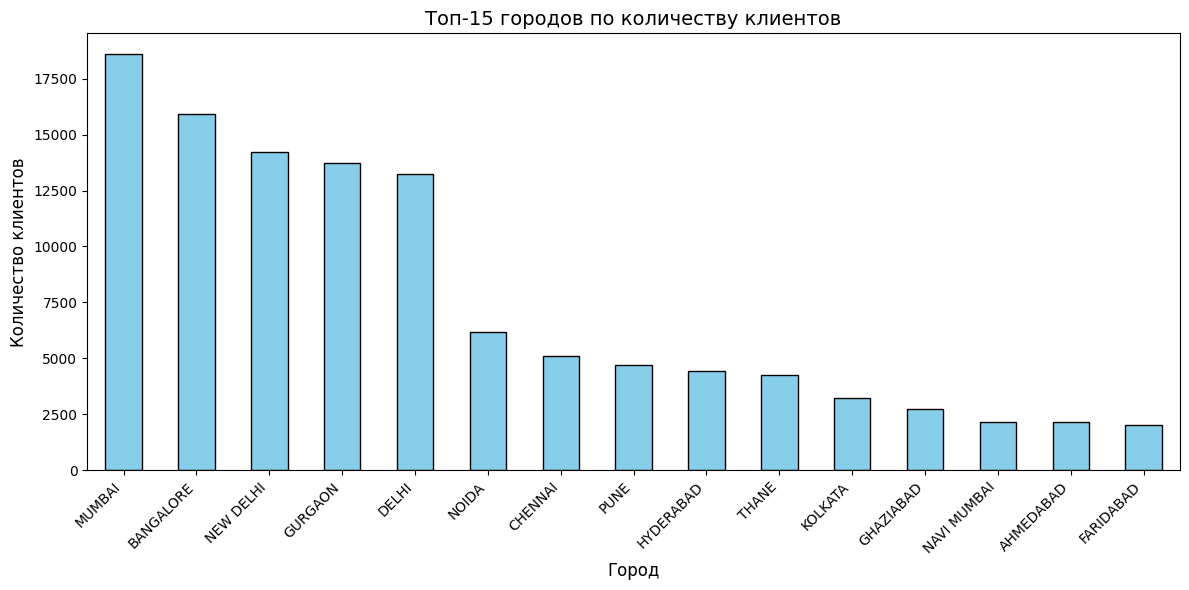

In [35]:
print("\n" + "="*50)
print("5.6 АНАЛИЗ ГОРОДОВ")
print("="*50)

city_counts = df['custlocation'].value_counts()
print(f"📊 Всего городов: {len(city_counts)}")
print(f"📊 Топ-10 городов:")
for city, count in city_counts.head(10).items():
    print(f"   {city}: {count}")

plt.figure(figsize=(12, 6))
city_counts.head(15).plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Топ-15 городов по количеству клиентов', fontsize=14)
plt.xlabel('Город', fontsize=12)
plt.ylabel('Количество клиентов', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


5.7 ДИНАМИКА ТРАНЗАКЦИЙ ПО ДАТАМ


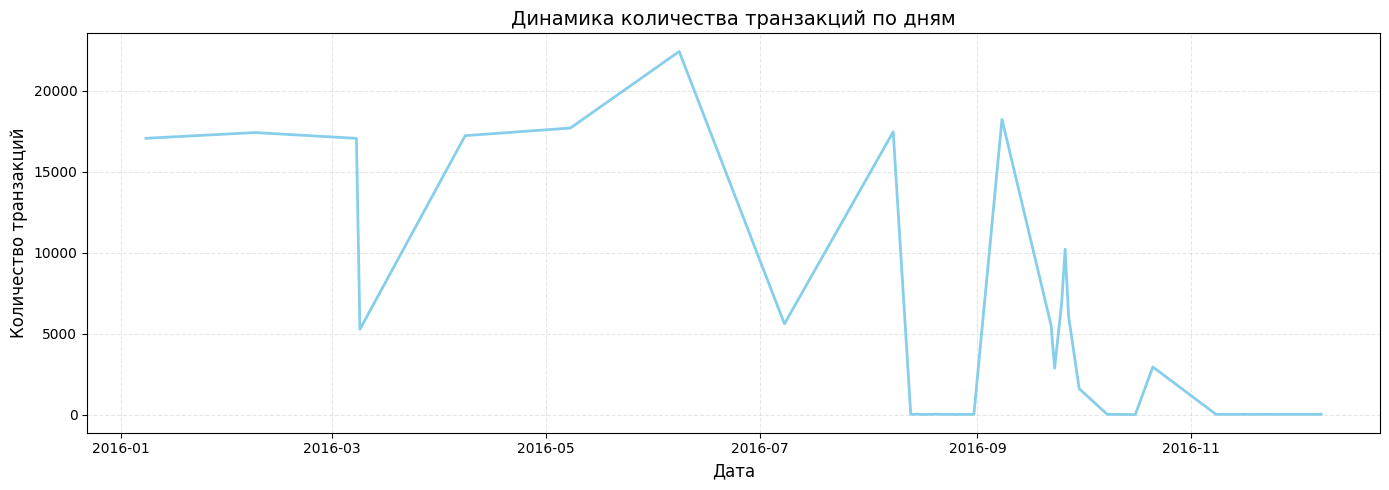

📊 Пик транзакций: 22425 (день: 2016-06-08)
📊 Среднее в день: 4796.9


In [36]:
print("\n" + "="*50)
print("5.7 ДИНАМИКА ТРАНЗАКЦИЙ ПО ДАТАМ")
print("="*50)

daily_trans = df.groupby(df['transactiondate'].dt.date).size()

plt.figure(figsize=(14, 5))
daily_trans.plot(color='skyblue', linewidth=2)
plt.title('Динамика количества транзакций по дням', fontsize=14)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Количество транзакций', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"📊 Пик транзакций: {daily_trans.max()} (день: {daily_trans.idxmax()})")
print(f"📊 Среднее в день: {daily_trans.mean():.1f}")


5.8 ДИНАМИКА ВЫРУЧКИ ПО ДНЯМ


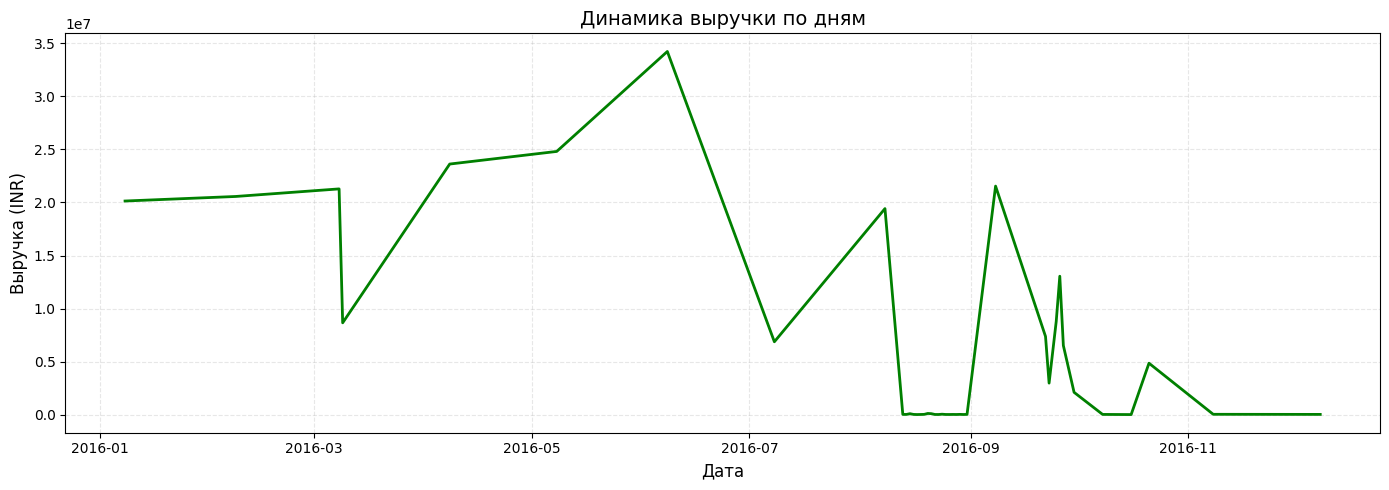

📊 Общая выручка: 247,314,630.61 INR
📊 Средняя в день: 6,182,865.77 INR


In [37]:
print("\n" + "="*50)
print("5.8 ДИНАМИКА ВЫРУЧКИ ПО ДНЯМ")
print("="*50)

daily_revenue = df.groupby(df['transactiondate'].dt.date)['transactionamount (inr)'].sum()

plt.figure(figsize=(14, 5))
daily_revenue.plot(color='green', linewidth=2)
plt.title('Динамика выручки по дням', fontsize=14)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Выручка (INR)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"📊 Общая выручка: {daily_revenue.sum():,.2f} INR")
print(f"📊 Средняя в день: {daily_revenue.mean():,.2f} INR")


5.9 ПЛАТЕЖЕСПОСОБНОСТЬ ПО ВОЗРАСТНЫМ ГРУППАМ
age_group
36-45    1.538217e+08
26-35    5.138830e+07
46-55    4.191534e+07
19-25    1.866127e+05
0-18     2.663000e+03
56-65    0.000000e+00
65+      0.000000e+00
Name: transactionamount (inr), dtype: float64


/tmp/ipykernel_1904/1776802512.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_spend = df.groupby('age_group')['transactionamount (inr)'].sum().sort_values(ascending=False)


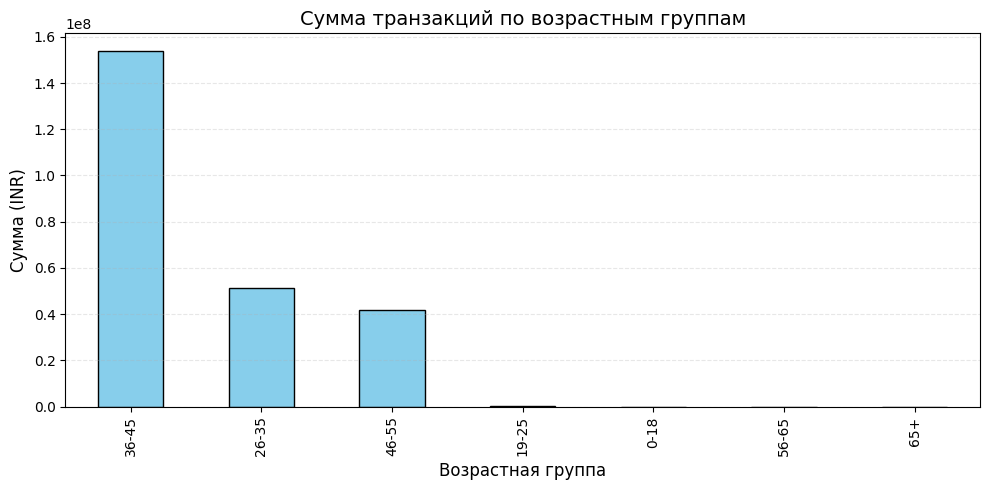


🏆 Самая платежеспособная группа: 36-45


In [38]:
print("\n" + "="*50)
print("5.9 ПЛАТЕЖЕСПОСОБНОСТЬ ПО ВОЗРАСТНЫМ ГРУППАМ")
print("="*50)

age_spend = df.groupby('age_group')['transactionamount (inr)'].sum().sort_values(ascending=False)

print(age_spend)

plt.figure(figsize=(10, 5))
age_spend.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Сумма транзакций по возрастным группам', fontsize=14)
plt.xlabel('Возрастная группа', fontsize=12)
plt.ylabel('Сумма (INR)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n🏆 Самая платежеспособная группа: {age_spend.index[0]}")

In [40]:
print("\n" + "="*50)
print("ЦИФРЫ ДЛЯ ИТОГА")
print("="*50)

# 1. Количество клиентов
customers = df['customerid'].nunique()
print(f"Всего клиентов: {customers}")

# 2. Общая выручка
total_revenue = df['transactionamount (inr)'].sum()
print(f"Общая выручка: {total_revenue:,.2f} INR")

# 3. Топ-3 города
top_cities = df['custlocation'].value_counts().head(3)
print("Топ-3 города:")
for city, count in top_cities.items():
    print(f"  {city}: {count}")

# 4. Пол
gender_counts = df['custgender'].value_counts()
print("Пол:")
for gender, count in gender_counts.items():
    print(f"  {gender}: {count} ({count/len(df)*100:.1f}%)")

# 5. Самая платежеспособная группа
top_group = df.groupby('age_group')['transactionamount (inr)'].sum().sort_values(ascending=False).index[0]
print(f"Самая платежеспособная группа: {top_group}")

# 6. Среднее транзакций на клиента
avg_trans = len(df) / customers
print(f"Среднее транзакций на клиента: {avg_trans:.2f}")


ЦИФРЫ ДЛЯ ИТОГА
Всего клиентов: 185703
Общая выручка: 247,314,630.61 INR
Топ-3 города:
  MUMBAI: 18594
  BANGALORE: 15927
  NEW DELHI: 14218
Пол:
  M: 138123 (72.0%)
  F: 53754 (28.0%)
Самая платежеспособная группа: 36-45
Среднее транзакций на клиента: 1.03


/tmp/ipykernel_1904/2398616633.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_group = df.groupby('age_group')['transactionamount (inr)'].sum().sort_values(ascending=False).index[0]


In [42]:
print("="*50)
print("ИТОГИ АНАЛИЗА БАНКОВСКОГО КЕЙСА")
print("="*50)
print()
print("1. ОБЩАЯ СТАТИСТИКА")
print(f"   Всего транзакций: {len(df)}")
print(f"   Всего клиентов: {df['customerid'].nunique()}")
print(f"   Общая выручка: {df['transactionamount (inr)'].sum():,.2f} INR")
print(f"   Средний чек: {df['transactionamount (inr)'].mean():.2f} INR")
print(f"   Медианный чек: {df['transactionamount (inr)'].median():.2f} INR")
print()
print("2. КЛИЕНТСКИЙ ПРОФИЛЬ")
print(f"   Средний возраст: {df['age'].mean():.1f} лет")
print("   Пол:")
for gender, count in df['custgender'].value_counts().items():
    print(f"      {gender}: {count} ({count/len(df)*100:.1f}%)")
print("   Топ-3 города:")
for city, count in df['custlocation'].value_counts().head(3).items():
    print(f"      {city}: {count}")
print()
print("3. ТРАНЗАКЦИОННАЯ АКТИВНОСТЬ")
print(f"   Среднее транзакций на клиента: {len(df)/df['customerid'].nunique():.2f}")
print(f"   Средний баланс: {df['custaccountbalance'].mean():,.2f} INR")
print(f"   Медианный баланс: {df['custaccountbalance'].median():,.2f} INR")

ИТОГИ АНАЛИЗА БАНКОВСКОГО КЕЙСА

1. ОБЩАЯ СТАТИСТИКА
   Всего транзакций: 191877
   Всего клиентов: 185703
   Общая выручка: 247,314,630.61 INR
   Средний чек: 1288.92 INR
   Медианный чек: 385.00 INR

2. КЛИЕНТСКИЙ ПРОФИЛЬ
   Средний возраст: 38.5 лет
   Пол:
      M: 138123 (72.0%)
      F: 53754 (28.0%)
   Топ-3 города:
      MUMBAI: 18594
      BANGALORE: 15927
      NEW DELHI: 14218

3. ТРАНЗАКЦИОННАЯ АКТИВНОСТЬ
   Среднее транзакций на клиента: 1.03
   Средний баланс: 71,870.64 INR
   Медианный баланс: 13,739.94 INR
